<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
## Write your code here
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

In [3]:
df.dtypes

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [5]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [6]:
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])

In [7]:
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0, 
    'More than 50 years': 51
})

In [8]:
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())

In [9]:
df['EdLevel'].isnull().sum()

np.int64(4653)

In [10]:
df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

In [11]:
ed_map = {
    'Primary/elementary school': 'Primary school',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'Bachelor',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master',
    'Some college/university study without earning a degree': 'Some college',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Secondary school',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Professional degree',
    'Associate degree (A.A., A.S., etc.)': 'Associate degree'
}

df['EdLevel'] = df['EdLevel'].replace(ed_map)

In [12]:
df['EdLevel'] = df['EdLevel'].fillna(df['EdLevel'].mode()[0])

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [13]:
## Write your code here
df['Employment'].value_counts().head(20)

Employment
Employed, full-time                                                                        39041
Independent contractor, freelancer, or self-employed                                        4846
Student, full-time                                                                          4709
Employed, full-time;Independent contractor, freelancer, or self-employed                    3557
Not employed, but looking for work                                                          2341
Employed, part-time                                                                         1266
Student, full-time;Employed, part-time                                                      1115
Employed, full-time;Student, full-time                                                       897
Employed, full-time;Student, part-time                                                       839
Student, full-time;Not employed, but looking for work                                        686
Not employed, and n

In [14]:
df['JobSat'].value_counts()

JobSat
7.0     42690
8.0      7509
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
0.0       311
1.0       276
Name: count, dtype: int64

In [15]:
df['YearsCodePro'].value_counts()

YearsCodePro
7.0    13827
2       4168
3       4093
5       3526
10      3251
4       3215
0       2856
6       2843
1       2639
8       2549
7       2517
12      1777
15      1635
20      1549
9       1493
11      1312
13      1127
14      1082
25       998
16       946
18       867
17       814
30       689
24       632
19       516
22       492
23       448
26       426
27       380
21       380
28       342
35       285
29       196
40       194
32       194
34       169
38       134
33       132
36       119
31       106
37       104
45        56
42        55
39        54
41        51
51        50
44        42
43        37
46        21
50        14
48        14
49        11
47        10
Name: count, dtype: int64

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


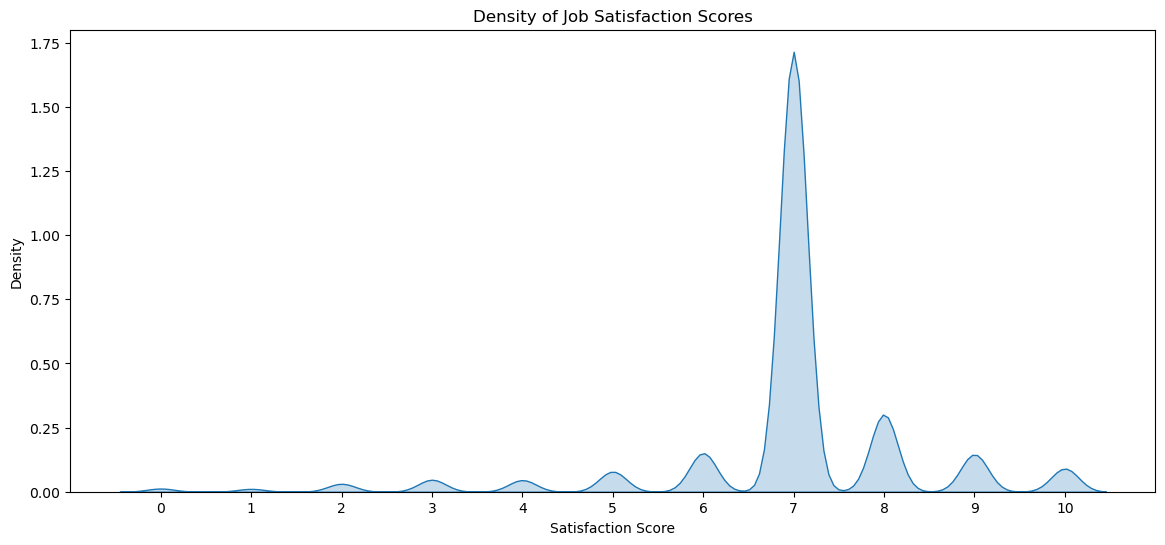

In [16]:
plt.figure(figsize = (14, 6))
sns.kdeplot(df['JobSat'], fill = True)
plt.xlabel('Satisfaction Score')
plt.ylabel('Density')
plt.xticks(range(0, 11))
plt.title('Density of Job Satisfaction Scores')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [17]:
## Write your code here
work_lang = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
want_lang = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()

In [18]:
comparison_df = pd.DataFrame({
    'HaveWorkedWith': work_lang,
    'WantToWorkWith': want_lang
}).fillna(0)
comparison_df.head()

,HaveWorkedWith,WantToWorkWith
Ada,542,558
Apex,502,389
Assembly,3233,3007
Bash/Shell (all shells),20412,13744
C,12184,8275


In [19]:
comparison_df = comparison_df.sort_values(by='HaveWorkedWith', ascending=False).head(25)

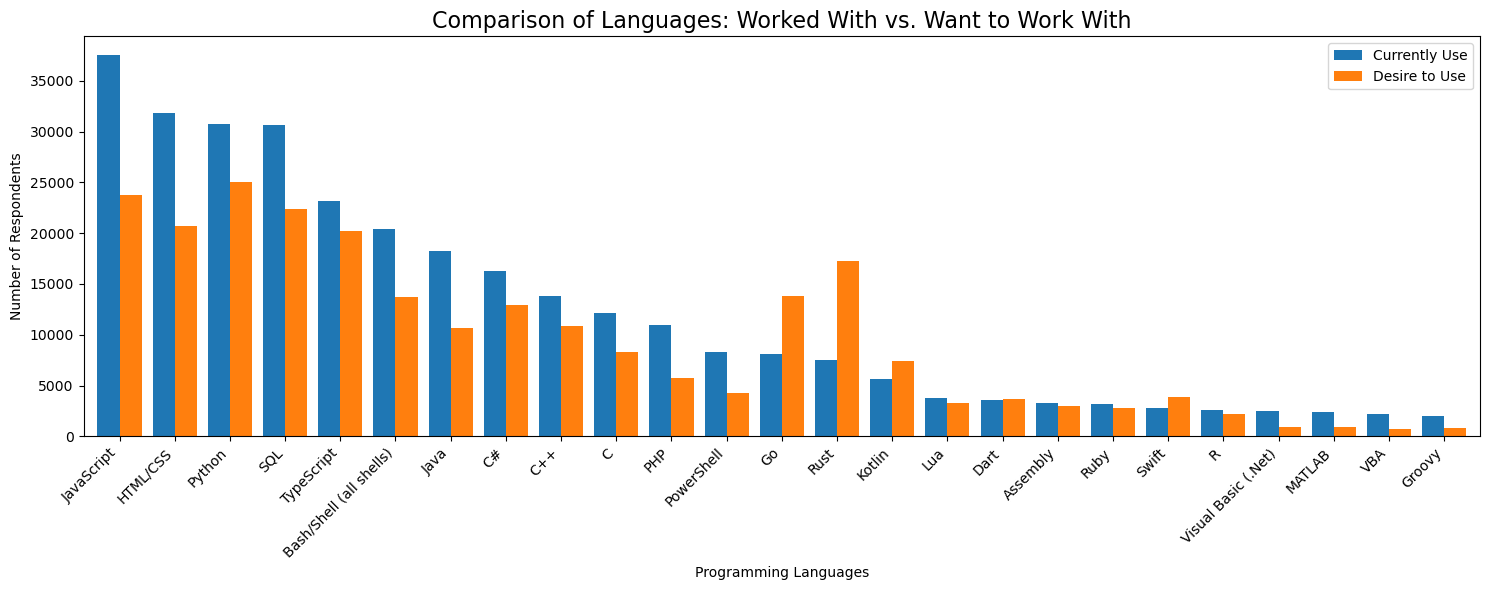

In [20]:
comparison_df.plot(kind = 'bar', figsize = (15, 6), width = 0.8)
plt.xlabel('Programming Languages')
plt.ylabel('Number of Respondents')
plt.title('Comparison of Languages: Worked With vs. Want to Work With', fontsize = 16)
plt.xticks(rotation = 45, ha = 'right')
plt.legend(['Currently Use', 'Desire to Use'])
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [21]:
top25_countries = df['Country'].value_counts().nlargest(25).index

In [22]:
df_top25 = df[df['Country'].isin(top25_countries)]

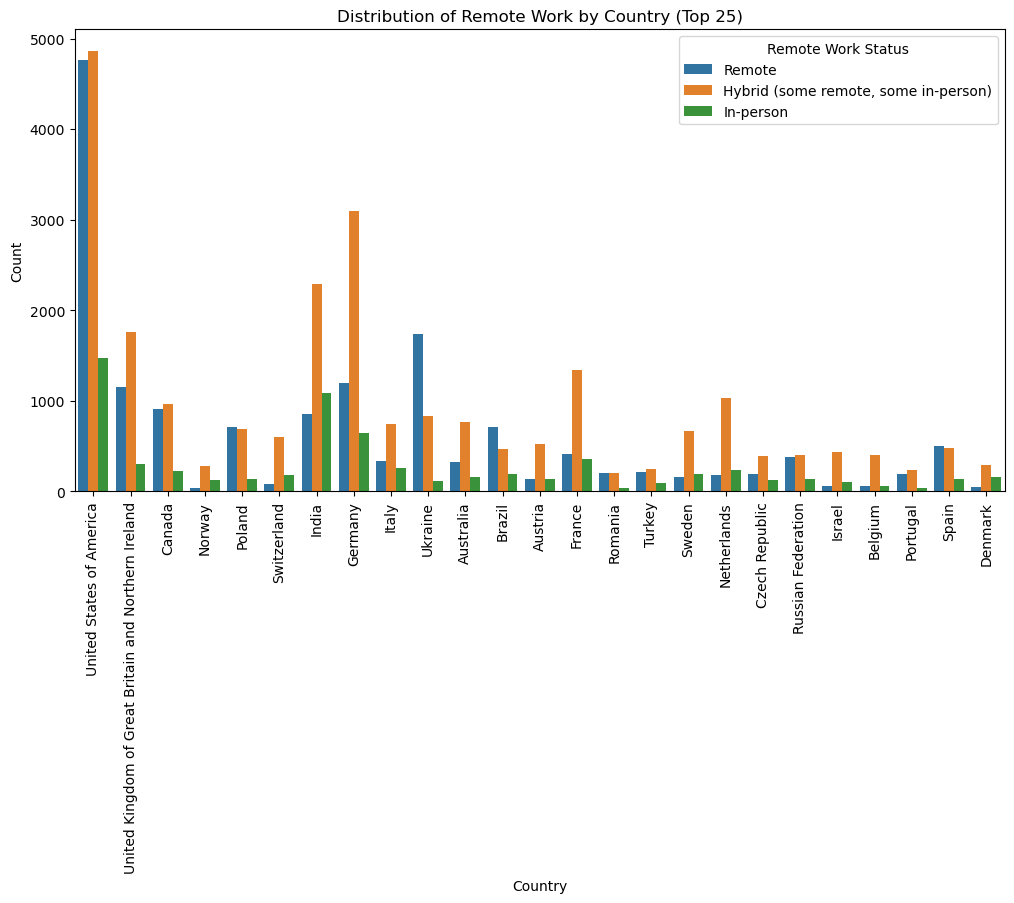

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data = df_top25, x = 'Country', hue = 'RemoteWork')
plt.title('Distribution of Remote Work by Country (Top 25)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.legend(title='Remote Work Status')
plt.show()

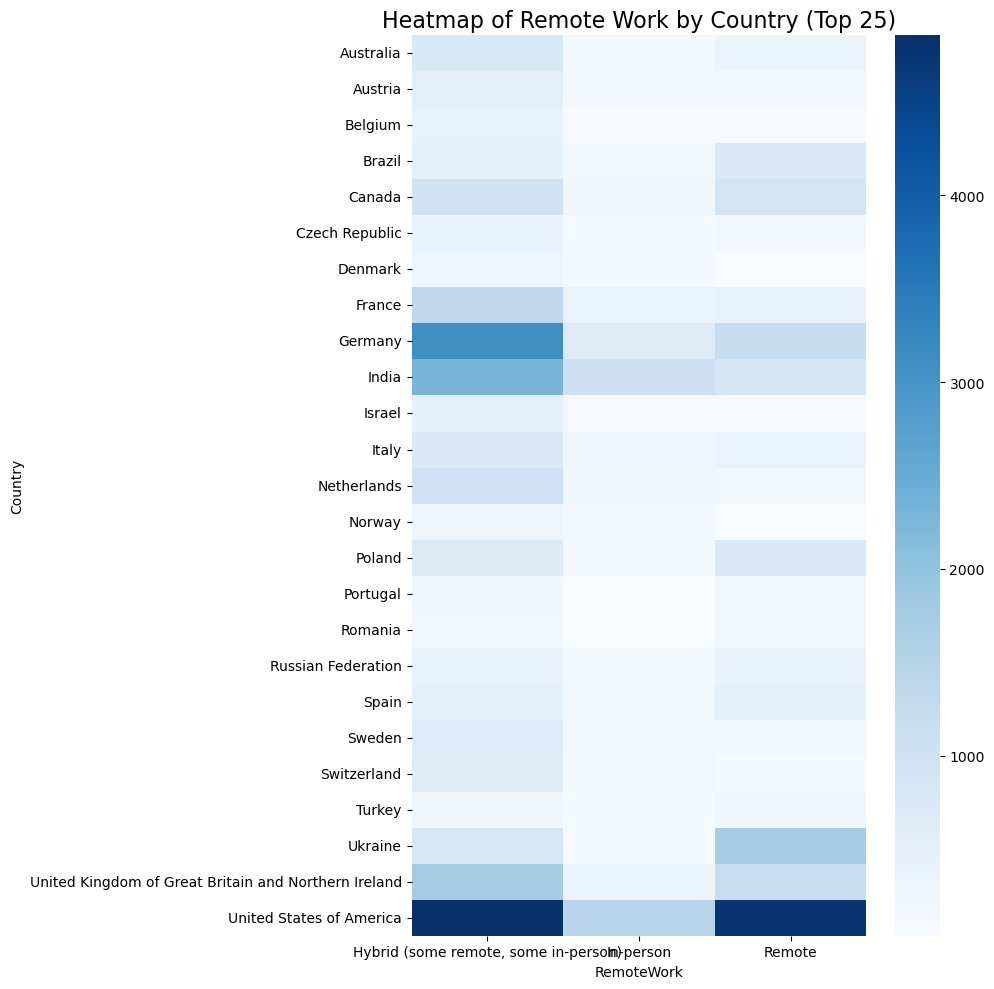

In [24]:
work_country_counts = pd.crosstab(df_top25['Country'], df_top25['RemoteWork'])
plt.figure(figsize = (10, 10))
sns.heatmap(work_country_counts, cmap='Blues')
plt.title('Heatmap of Remote Work by Country (Top 25)', fontsize = 16)
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [25]:
## Write your code here
correlation = df['JobSat'].corr(df['YearsCodePro'], method = 'spearman')
correlation

np.float64(0.09074418034330173)

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


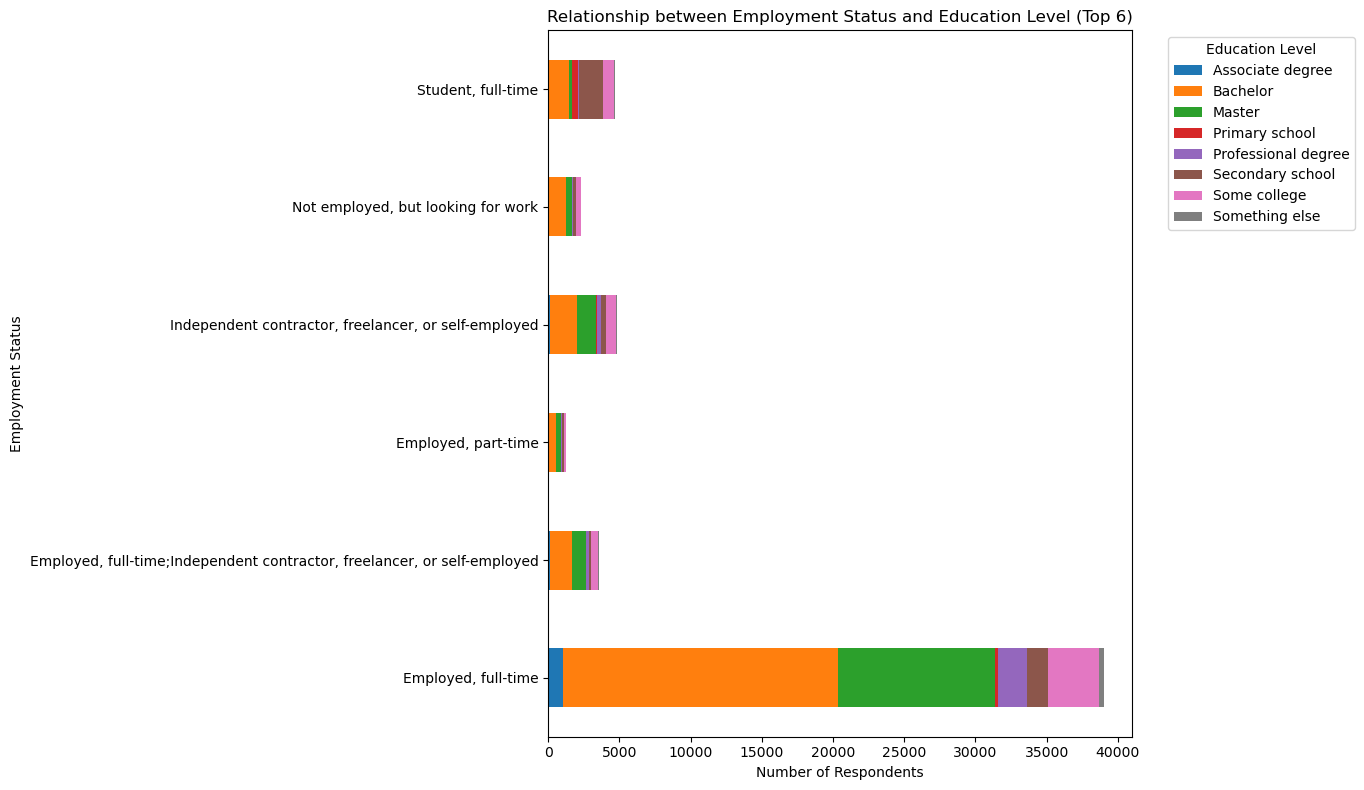

In [26]:
top_6_emp = df['Employment'].value_counts().nlargest(6).index
df_emp_filtered = df[df['Employment'].isin(top_6_emp)]
cross_tab = pd.crosstab(df_emp_filtered['Employment'], df_emp_filtered['EdLevel'])
cross_tab.plot(kind = 'barh', stacked = True, figsize = (14, 8))
plt.title('Relationship between Employment Status and Education Level (Top 6)')
plt.xlabel('Number of Respondents')
plt.ylabel('Employment Status')
plt.legend(title = 'Education Level', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [27]:
## Write your code here
df.to_csv('from_lab13_cleaned_survey_data.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
